In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
path = r"H:\python\python-tecTI\dados\Tabelas\Tabela4.csv"

In [7]:
df = pd.read_csv(path, sep=";", decimal=",", encoding="latin-1")
df = df.dropna(how="all", axis=1)

In [17]:
print(df_ordenado.head())

  Sigla  Codigo  Estado   1991   2000   2010   2012   2013   2014   2015  \
0    AC      12     NaN  0.402  0.517  0.663  0.705  0.709  0.719  0.719   
1    AL      27     NaN  0.370  0.471  0.631  0.657  0.653  0.670  0.669   
2    AM      13     NaN  0.430  0.515  0.674  0.706  0.717  0.720  0.724   
3    AP      16     NaN  0.472  0.577  0.708  0.709  0.735  0.726  0.728   
4    BA      29     NaN  0.386  0.512  0.660  0.684  0.686  0.700  0.708   

    2016   2017   2018   2019   2020   2021   2022   2023   2024  
0  0.723  0.711  0.731  0.738  0.736  0.702  0.732  0.740  0.754  
1  0.680  0.682  0.694  0.693  0.694  0.691  0.722  0.739  0.746  
2  0.723  0.743  0.732  0.739  0.725  0.700  0.757  0.764  0.767  
3  0.732  0.731  0.737  0.732  0.707  0.681  0.743  0.767  0.759  
4  0.708  0.715  0.714  0.723  0.726  0.698  0.734  0.740  0.759  


In [14]:
df_ordenado = df.iloc[1:27].copy()
df_ordenado.columns = [
    "Sigla",
    "Codigo",
    "Estado",
    "1991", "2000", "2010", "2012", "2013", "2014","2015", "2016", 
    "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024",
]
df_ordenado = df_ordenado.reset_index(drop=True)

for col in df_ordenado.columns[1:]:
    df_ordenado[col] = pd.to_numeric(df_ordenado[col], errors="coerce")

In [18]:
df_ordenado2024 = df_ordenado.sort_values(by="2024", ascending=False)
print(df_ordenado2024[["Sigla", "Estado", "2024"]])

   Sigla  Estado   2024
6     DF     NaN  0.866
25    SP     NaN  0.838
23    SC     NaN  0.833
17    PR     NaN  0.822
18    RJ     NaN  0.819
22    RS     NaN  0.818
8     GO     NaN  0.815
12    MT     NaN  0.812
10    MG     NaN  0.809
7     ES     NaN  0.804
11    MS     NaN  0.797
20    RO     NaN  0.786
21    RR     NaN  0.780
19    RN     NaN  0.778
5     CE     NaN  0.773
2     AM     NaN  0.767
15    PE     NaN  0.767
16    PI     NaN  0.764
24    SE     NaN  0.761
14    PB     NaN  0.760
3     AP     NaN  0.759
4     BA     NaN  0.759
13    PA     NaN  0.758
0     AC     NaN  0.754
1     AL     NaN  0.746
9     MA     NaN  0.745


In [21]:
df_ordenado["Melhora"] = df_ordenado["2024"] - df_ordenado["1991"]
estado_maior_melhora = df_ordenado.sort_values(by="Melhora", ascending=False).iloc[0]
print(
    f"Maior melhora: {estado_maior_melhora['Estado']} ({estado_maior_melhora['Sigla']}) "
    f"com ganho de {estado_maior_melhora['Melhora']:.3f}"
)

Maior melhora: nan (PI) com ganho de 0.402


In [22]:
piorou = df_ordenado[df_ordenado["Melhora"] < 0]
if piorou.empty:
    print("Nenhum estado teve piora no IDH entre 1991 e 2024.")
else:
    print("Estados que pioraram:")
    print(piorou[["Estado", "Melhora"]])

Nenhum estado teve piora no IDH entre 1991 e 2024.


In [23]:
anos = [c for c in df_ordenado.columns if str(c).isdigit()]

id_vars = [c for c in df_ordenado.columns if c not in anos and c != "Melhora"]

df_longo = df_ordenado.melt(
    id_vars=id_vars, value_vars=anos, var_name="Ano", value_name="IDH"
)

df_longo["Ano"] = df_longo["Ano"].astype(int)
df_longo["IDH"] = pd.to_numeric(df_longo["IDH"], errors="coerce")

print("\nDados transformados (Formato Longo):")
print(df_longo.head())


Dados transformados (Formato Longo):
  Sigla  Codigo  Estado   Ano    IDH
0    AC      12     NaN  1991  0.402
1    AL      27     NaN  1991  0.370
2    AM      13     NaN  1991  0.430
3    AP      16     NaN  1991  0.472
4    BA      29     NaN  1991  0.386


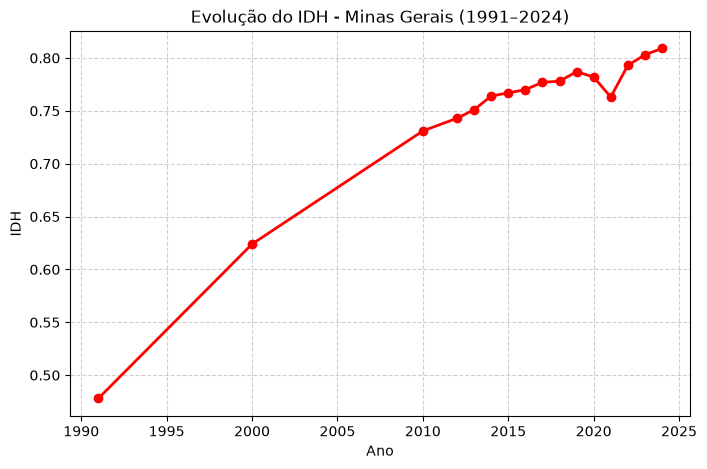

In [24]:
df_mg = df_longo[df_longo["Sigla"] == "MG"].sort_values("Ano")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_mg["Ano"], df_mg["IDH"], marker="o", color="red", linewidth=2)
ax.set_title("Evolução do IDH - Minas Gerais (1991–2024)")
ax.set_xlabel("Ano")
ax.set_ylabel("IDH")
ax.grid(True, linestyle="--", alpha=0.6)
plt.show()

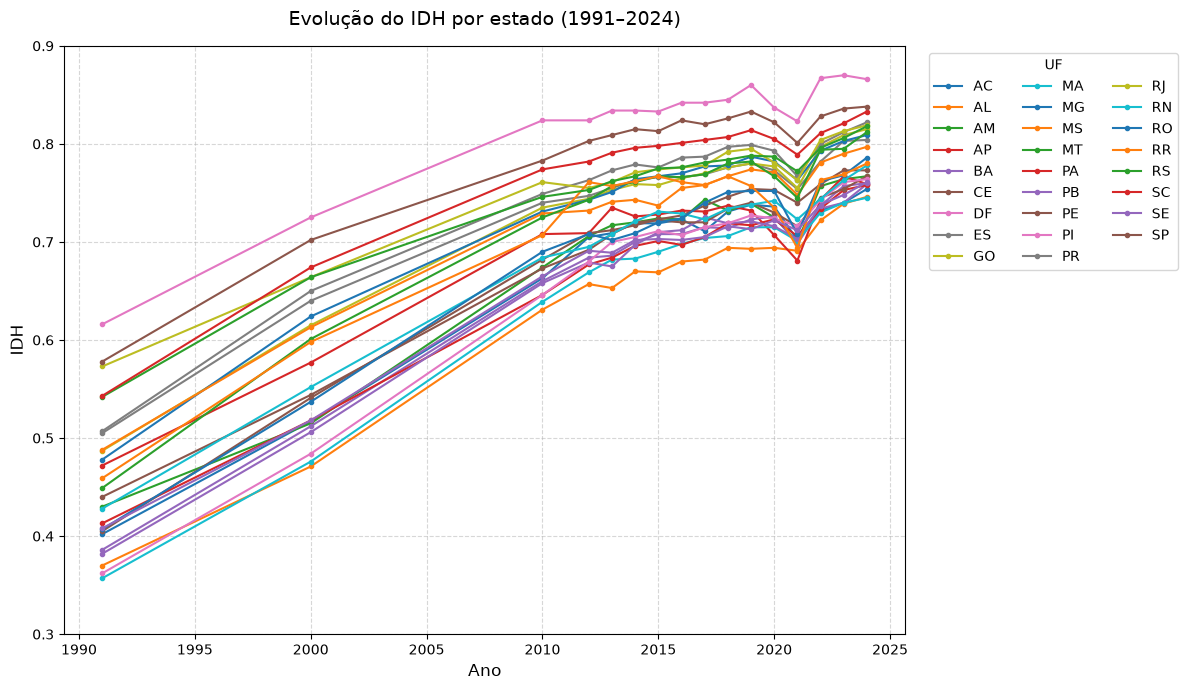

In [25]:
fig, ax = plt.subplots(figsize=(12, 7))

for sigla, grupo in df_longo.groupby("Sigla"):
    grupo = grupo.sort_values("Ano")
    ax.plot(
        grupo["Ano"],
        grupo["IDH"],
        marker="o",
        markersize=3,
        linewidth=1.5,
        label=sigla,
    )

ax.set_title("Evolução do IDH por estado (1991–2024)", fontsize=14, pad=15)
ax.set_xlabel("Ano", fontsize=12)
ax.set_ylabel("IDH", fontsize=12)
ax.set_ylim(0.3, 0.9)
ax.grid(True, linestyle="--", alpha=0.5)

ax.legend(ncol=3, bbox_to_anchor=(1.02, 1), loc="upper left", title="UF")

fig.tight_layout()
plt.show()